# Wikimedia Project

Indoor vs outdoor image classification project report.

## 1. Data Sources
- WIT dataset (wikimedia/wit_base)
- Candidate pool created with CLIP filtering

In [1]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image

sns.set_theme(style='whitegrid')

In [2]:
# Paths
ROOT = Path('..')
POOL_DIR = ROOT / 'pool'
TRAIN_DIR = ROOT / 'train_set'

POOL_LABELS = POOL_DIR / 'labels.csv'
TRAIN_LABELS = TRAIN_DIR / 'labels.csv'

In [3]:
# Load labels if they exist
pool_df = pd.read_csv(POOL_LABELS) if POOL_LABELS.exists() else None
train_df = pd.read_csv(TRAIN_LABELS) if TRAIN_LABELS.exists() else None

pool_df.head() if pool_df is not None else 'Pool labels not found'

,image_id,url,width,height,photo_prob,inside_prob,outside_prob,weak_label
0,img_0000000,NaN,300,431,0.8709,0.8817,0.1183,inside
1,img_0000001,NaN,300,400,0.9730,0.0067,0.9933,outside
2,img_0000002,NaN,300,437,0.9536,0.6584,0.3416,inside
3,img_0000003,NaN,300,400,0.9371,0.9960,0.0040,inside
4,img_0000004,NaN,300,400,0.8995,0.0898,0.9102,outside


In [4]:
# Candidate pool stats
if pool_df is not None:
    display(pool_df['weak_label'].value_counts())
    display(pool_df[['photo_prob', 'inside_prob', 'outside_prob']].describe())

weak_label
inside     10000
outside    10000
Name: count, dtype: int64

,photo_prob,inside_prob,outside_prob
count,20000.000000,20000.000000,20000.000000
mean,0.911247,0.482927,0.517073
std,0.074294,0.351941,0.351941
min,0.700000,0.000600,0.000100
25%,0.872775,0.128275,0.190400
50%,0.936500,0.500050,0.499950
75%,0.969100,0.809600,0.871725
max,0.999200,0.999900,0.999400


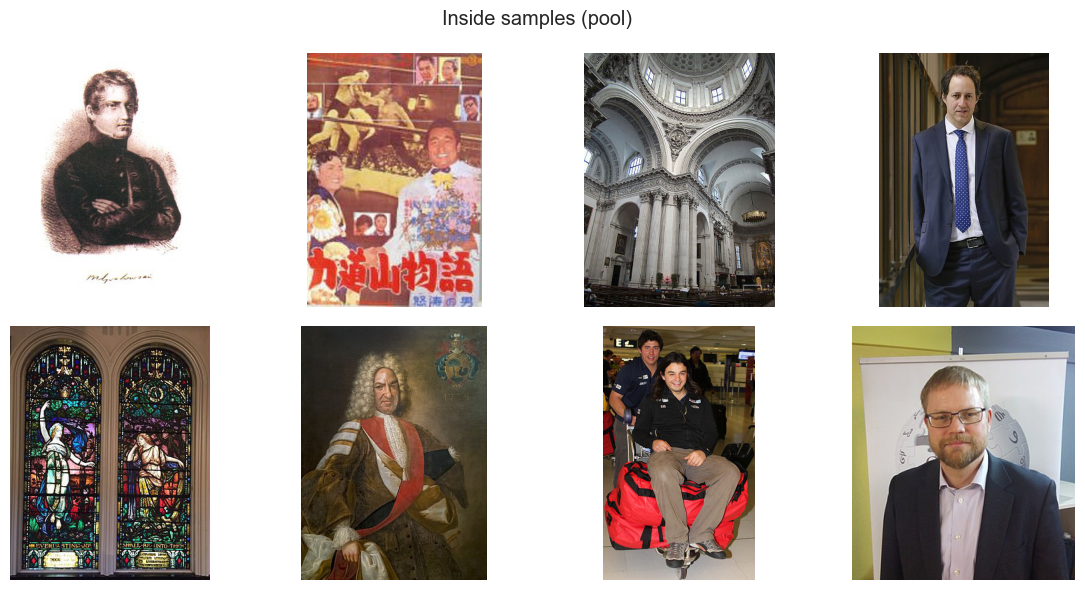

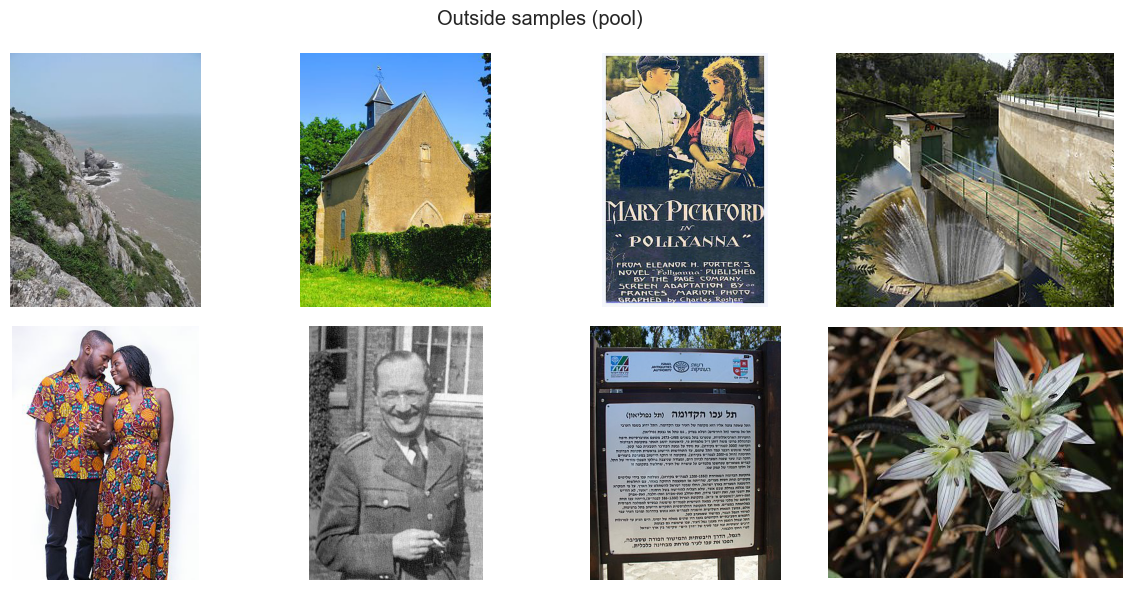

In [6]:
# Show a grid of sample images
def show_grid(image_paths, rows=2, cols=4, title=None):
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten()
    for ax, path in zip(axes, image_paths):
        img = Image.open(path)
        ax.imshow(img)
        ax.axis('off')
    if title:
        fig.suptitle(title)
    fig.tight_layout()
    plt.show()

inside_paths = list((POOL_DIR / 'inside').glob('*.jpg'))[:8]
outside_paths = list((POOL_DIR / 'outside').glob('*.jpg'))[:8]
if inside_paths:
    show_grid(inside_paths, title='Inside samples (pool)')
if outside_paths:
    show_grid(outside_paths, title='Outside samples (pool)')